In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Set random seeds for reproducibility
np.random.seed(180)
tf.random.set_seed(180)

In [2]:
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
print("Data shape:", people.data.shape)
print("Target shape:", people.target.shape)
image_shape = people.images[0].shape

Data shape: (3023, 5655)
Target shape: (3023,)


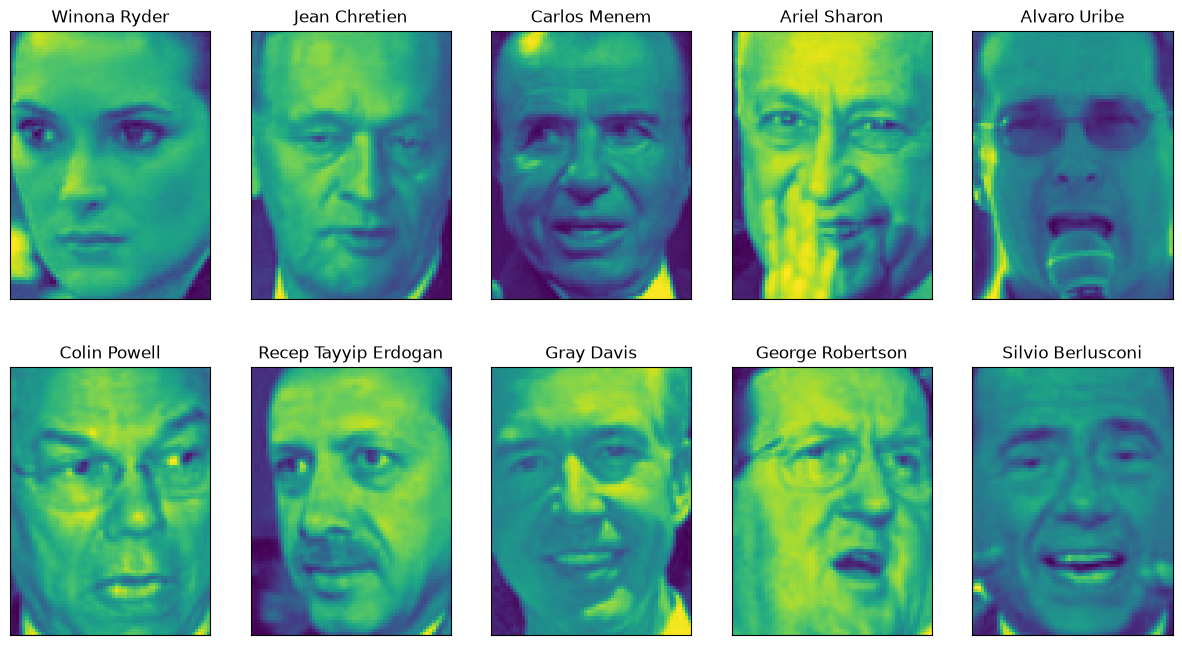

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8), subplot_kw={'xticks': (), 'yticks': ()})
for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    people.data, people.target, test_size=0.2, random_state=20
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("people.images.shape: {}".format(people.images.shape))
print("Number of classes: {}".format(len(people.target_names)))
counts = np.bincount(people.target)
for i, (count, name) in enumerate(zip(counts, people.target_names)):
    print("{0:25} {1:3}".format(name, count), end="")
    if (i + 1) % 3 == 0:
        print()

X_train shape: (2418, 5655)
y_train shape: (2418,)
y_test shape: (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62
Alejandro Toledo           39Alvaro Uribe               35Amelie Mauresmo            21
Andre Agassi               36Angelina Jolie             20Ariel Sharon               77
Arnold Schwarzenegger      42Atal Bihari Vajpayee       24Bill Clinton               29
Carlos Menem               21Colin Powell              236David Beckham              31
Donald Rumsfeld           121George Robertson           22George W Bush             530
Gerhard Schroeder         109Gloria Macapagal Arroyo    44Gray Davis                 26
Guillermo Coria            30Hamid Karzai               22Hans Blix                  39
Hugo Chavez                71Igor Ivanov                20Jack Straw                 28
Jacques Chirac             52Jean Chretien              55Jennifer Aniston           21
Jennifer Capriati          42Jennifer Lopez             21Jeremy Greenstock   

In [5]:
mask = np.zeros(people.target.shape, dtype=np.bool_)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = True
X_people = people.data[mask]
y_people = people.target[mask]
X_people = X_people / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0
)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print("Test set score of 1-NN: {:.2f}".format(knn.score(X_test, y_test)))

Test set score of 1-NN: 0.22


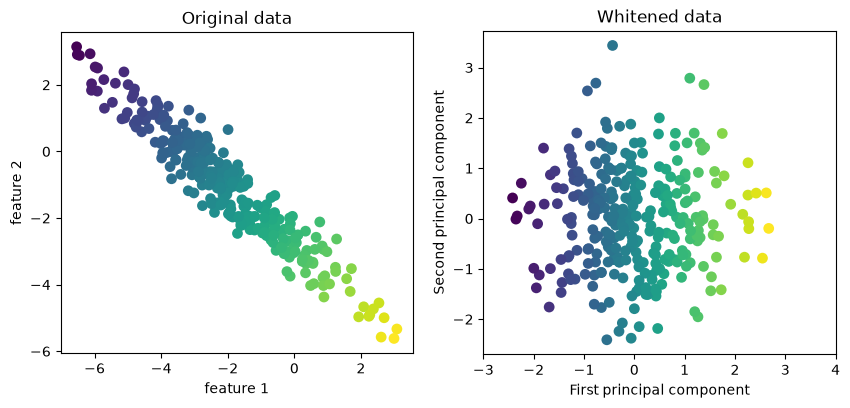

In [6]:

mglearn.plots.plot_pca_whitening()
plt.show()

In [7]:
pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("X_train_pca.shape: {}".format(X_train_pca.shape))
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)

print("Test set accuracy with PCA: {:.2f}".format(knn.score(X_test_pca, y_test)))
print("pca.components_.shape: {}".format(pca.components_.shape))

X_train_pca.shape: (1547, 100)
Test set accuracy with PCA: 0.30
pca.components_.shape: (100, 5655)


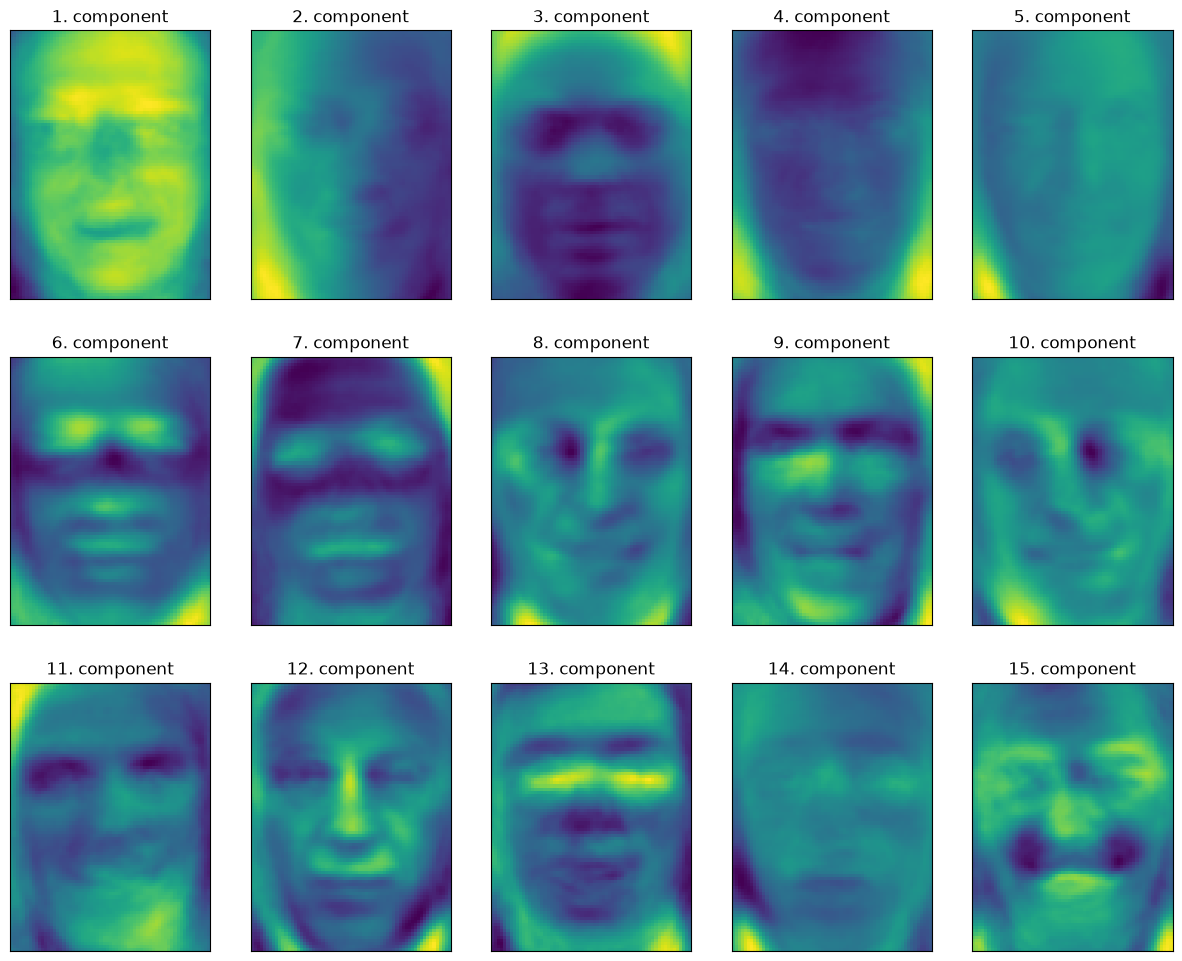

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(15, 12), subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(pca.components_[:15], axes.ravel())):
    ax.imshow(component.reshape(image_shape), cmap='viridis')
    ax.set_title("{}. component".format(i + 1))
plt.show()

In [9]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)
model = Sequential([
    Input(shape=(100,)),
    Dense(300, activation='relu'),
    Dense(100, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train_scaled, 
    y_train, 
    batch_size=50, 
    epochs=20, 
    shuffle=False, 
    verbose=1
)
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0155 - loss: 4.1271
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0304 - loss: 4.0845
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0446 - loss: 4.0583
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0446 - loss: 4.0408
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0582 - loss: 4.0154
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0782 - loss: 3.9839
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1034 - loss: 3.9473
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1286 - loss: 3.9045
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1571 - loss: 3.8481
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1732 - loss: 3.7806
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1946 - loss: 3.6931
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2069 - l